In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus']=False

import tensorflow as tf
from tensorflow import keras
import model_lstm

# 读取训练好的神经网络模型，构建MPC系统

## 读取数据

In [2]:
data2=pd.read_csv('./Pool1/Training data_timeavg_ver2/Pool1_timeAvg_500^2_shaped.csv').values[:,2:]
#说明：之前数据为Pool1_timeAvg_3.csv，只有13列，前9个为状态变量（DO、MLSS、OPR），后4个为控制变量（曝气量）
#现有数据有22列，前9个为状态变量（DO、MLSS、OPR），后13个为控制变量（曝气量、进水COD、入流、外回流）
print(data2.shape)

da=pd.read_csv('./Pool1/Training data_timeavg_ver2/Pool1_timeAvg_500^2_shaped.csv')
print(da.columns)

(150000, 22)
Index(['Unnamed: 0', '日期', '6-1生物池DO1', '6-1生物池DO2', '6-1生物池DO3', '6-1生物池DO4',
       '6-1号生物池缺氧段MLSS', '6-1号生物池厌氧段MLSS', '6-1号生物池好氧段MLSS', '6-1号生物池缺氧段OPR',
       '6-1号生物池厌氧段OPR', '6-4号生物池NH3_2', '6-6号生物池好氧段NO3', '1号生物反应池瞬时流量',
       '进水COD', '进水氨氮', '进水TN', '进水TP', '6-1好氧段曝气量1', '6-1好氧段曝气量2',
       '6-1好氧段曝气量3', '6-1好氧段曝气量4', '内回流流量1', '7-1外回流流量1'],
      dtype='object')


## 归一化与反归一化方法

In [3]:
def normlization(data):
    ma=np.max(data,axis=0)
    mi=np.min(data,axis=0)
    tdata=data.copy()
    for i in range(tdata.shape[0]):
        tdata[i,:]=((data[i,:]-mi)/(ma-mi)-0.5)*2
    return tdata,ma,mi

def normlization_one(x,ma,mi):
    tx=x.copy()
    tx=((x-mi)/(ma-mi)-0.5)*2
    return tx

def re_normlization(tdata,ma,mi):
    data=tdata.copy()
    for i in range(data.shape[0]):
        data[i,:]=mi+(tdata[i,:]*0.5+0.5)*(ma-mi)
    return data

In [4]:
def figplt_vs(data,data_p):
    plt.figure(figsize=(30,25))
    for i in range(data.shape[1]):
        plt.subplot(data.shape[1],1,i+1)
        plt.plot(data[:,i],'r',label='True')
        plt.plot(data_p[:,i],'b',label='opt')
        #plt.xticks([])
        #plt.title(data.columns[i])
        plt.legend()

def figplt_vs_title(data,data_p,titles,savepath):
    plt.figure(figsize=(30,25))
    for i in range(data.shape[1]):
        plt.subplot(data.shape[1],1,i+1)
        plt.plot(data[:,i],'r',label='True')
        plt.plot(data_p[:,i],'b',label='Predict')
        #plt.xticks([])
        plt.ylabel(titles[i])
        plt.legend()
    if savepath==' ':
        pass
    else:
        plt.savefig(savepath)

In [5]:
td,ma,mi=normlization(data2)
print(ma.shape,mi.shape)

(22,) (22,)


## 选择测试编号 读取模型

In [6]:
params={}

params['time_steps']=10  #输入时间序列长度
params['input_size']=16+6
params['outputs_size']=11
#说明：之前控制变量4个，状态变量9个，共13个；
#现在控制变量6个，状态变量16个，所以上面list的“4+9”要改为“16+6”。
params['lr']=0.0001


# idd=1: 全数据测试
# idd=2: 1/3数据测试
# idd=3: 1/10数据测试

idd=2
idp=5

if idd==1:
    n=140000
elif idd==2:
    n=40000  #test1
else:
    n=10000  #test2

X_train,Y_train=[],[]
for it in range(n):
    X_train.append(td[it:it+params['time_steps'],:].tolist())
    Y_train.append(td[it+params['time_steps'],:params['outputs_size']].tolist())
X_train=np.array(X_train)
Y_train=np.array(Y_train)

print(X_train.shape,Y_train.shape)
    
#说明：之前控制变量4个，状态变量9个，共13个；
#现在控制变量13个，状态变量9个，所以上面挑选数据的下标要变（比如列号的9）。


if idp==1:
    params['lstm_size']=1
elif idp==2:
    params['lstm_size']=5
elif idp==3:
    params['lstm_size']=10
elif idp==4:
    params['lstm_size']=15
else:
    params['lstm_size']=20


################################################################
    #parameter set1: [[4+9,10],[10,10],[10,9]]
    #parameter set2: [[4+9,5],[5,5],[5,9]]
    #parameter set3: [[4+9,10],[10,9]]
    #parameter set4: [[4+9,10],[10,10],[10,10],[10,10],[10,9]]
    #parameter set5: [[4+9,10],[10,10],[10,10],[10,10],[10,10],[10,9]]
################################################################
#有误 需修改
n=140000
X_test,Y_test=[],[]
for it in range(n):
    X_test.append(td[it:it+params['time_steps'],:].tolist())
    Y_test.append(td[it+params['time_steps']+1,:params['outputs_size']].tolist())
X_test=np.array(X_test)
Y_test=np.array(Y_test)

#X_test=X_train.copy()
#Y_test=Y_train.copy()
print(X_test.shape,Y_test.shape)

(40000, 10, 22) (40000, 11)
(140000, 10, 22) (140000, 11)


D:\Software\Anaconda\lib\site-packages\keras\engine\training.py:2470: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  warnings.warn('`Model.state_updates` will be removed in a future version. '


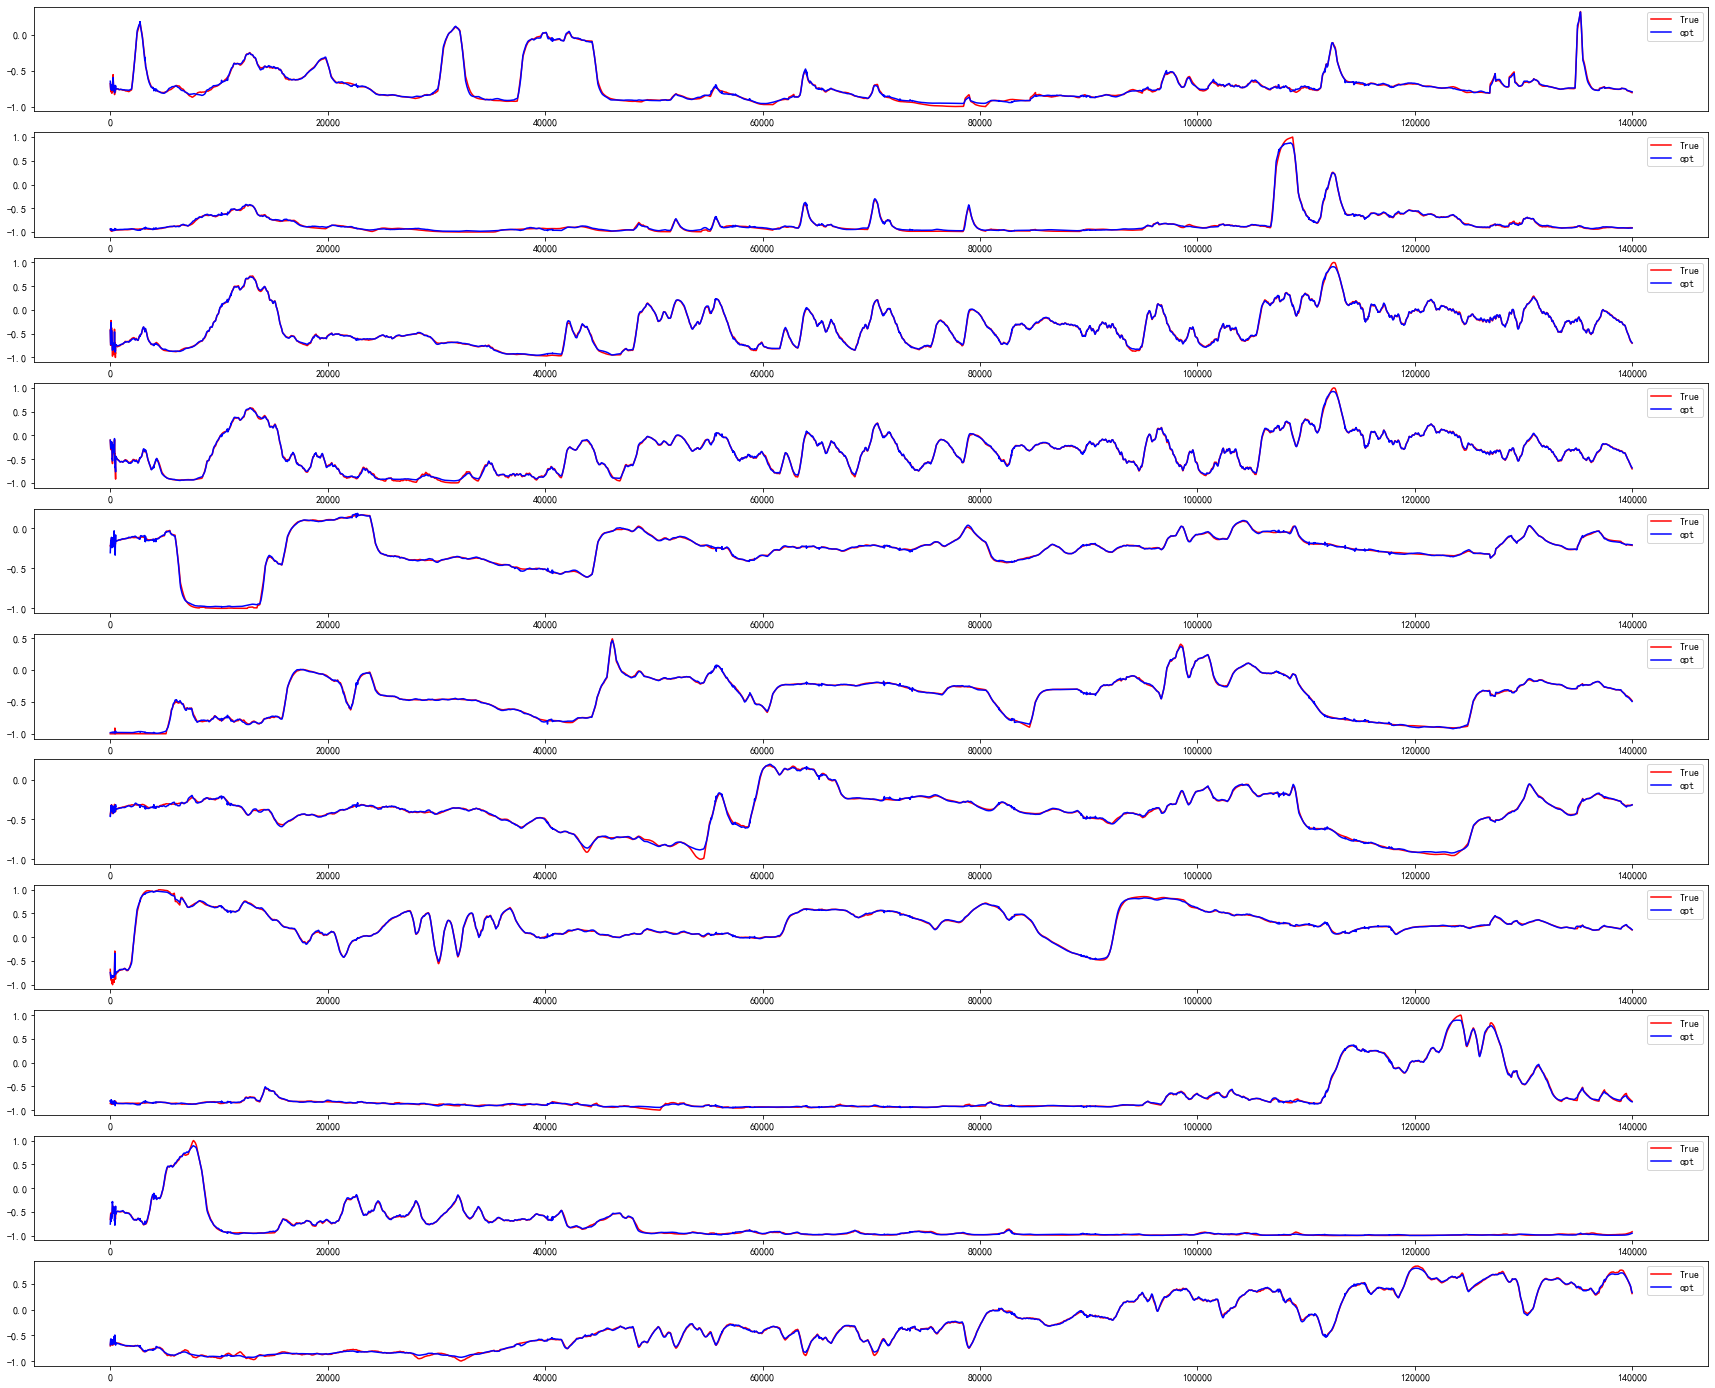

In [7]:
LSTM_model=model_lstm.model_lstm(params)
LSTM_model.layers()
#Load trained model
LSTM_model.model=keras.models.load_model('./LSTM 30min/LSTM30min/V1-30/LSTM parameters '+str(idp)+'/LSTM_model.h5')
#LSTM_model.model=keras.models.load_model('./LSTM 30min/LSTM2分两段/V3/LSTM parameters '+str(idp)+'/LSTM_model.h5')

y1=LSTM_model.model.predict(X_test)

figplt_vs(Y_test[:,:].reshape(-1,11),y1[:,:])

# 将上述模型用于MPC

In [8]:
import pso
import time

## 当前案例：控制MLSS在2到4.5之间，控制曝气量尽量小，内回流在1.1-1.5，外回流在0.5-1，控制时间长度100个时间步

In [9]:
def load_model():
    LSTM_model=model_lstm.model_lstm(params)
    LSTM_model.layers()
    #Load trained model
    LSTM_model.model=keras.models.load_model('./LSTM 30min/LSTM30min/V1-30/LSTM parameters '+str(idp)+'/LSTM_model.h5')
    return LSTM_model

def one_step(LSTM_model,X_init,X_state,x):
    #X_init.shape=(1,9,22)
    #X_state.shape=(1,1,10)
    #x.shape=(1,1,12)
    temx=np.concatenate((X_state,x),axis=2)
    X=np.concatenate((X_init,temx),axis=1)
    
    y1=LSTM_model.model.predict(X)
    #Y_data=re_normlization(y1,ma[:9],mi[:9])
        
    return y1

def calobjValue(X,X_init,X_state,model):
    
    obj_value=[]
    J,G=[],[]
    for i in range(X.shape[0]):
        #x = temp1[i] * max_value / (math.pow(2, chrom_length) - 1)
        #要把每个pop变成控制变量，现在已经代表了6个控制变量
        control_d=X.shape[1]
        #x=re_normlization(X[i].reshape((1,control_d)),ma[22-control_d:22],mi[22-control_d:22]).reshape(1,1,-1)
        x=X[i].reshape((1,1,control_d))
        Y=one_step(model,X_init,X_state,x)
        
        # 22 个输入量，每个的范围。标准范围 & 历史数据范围
        #控制MLSS在2到4.5之间
        if Y[0,5]>=2:
            v1=np.exp(-np.abs(Y[0,5]-2))
        elif Y[0,5]<=4.5:
            v1=np.exp(-np.abs(Y[0,5]-4.5))
        else:
            v1=1
        
        #控制DO在一定范围
        if Y[0,2]>=0:
            v2=np.exp(-np.abs(Y[0,2]))
        elif Y[0,2]<=0.2:
            v2=np.exp(-np.abs(Y[0,2]-0.2))
        else:
            v2=1
        
        if Y[0,1]>=0.2:
            v3=np.exp(-np.abs(Y[0,1]-0.2))
        elif Y[0,1]<=0.5:
            v3=np.exp(-np.abs(Y[0,1]-0.5))
        else:
            v3=1
            
        if Y[0,3]>=2:
            v4=np.exp(-np.abs(Y[0,3]-2))
        elif Y[0,3]<=3.5:
            v4=np.exp(-np.abs(Y[0,3]-3.5))
        else:
            v4=1
            
        #增加最后一个DO
            
        #控制曝气量尽可能低
        v5=0
        s=[23.56,34.02,19.38,17.47]
        
        for i in range(4):
            v5+=np.exp(-np.abs(x[0][0][i]-0))
        
        #控制回流比稳定
        #本来应该内回流比=内回流/进水，外回流比=外回流/进水，直接相除得关注的数据是：内回流/外回流
        v6=0
        xstate=re_normlization(X_state,ma[:16],mi[:16])
        outflow=xstate[:,:,-1][0][0] 
        inflow=xstate[:,:,-2][0][0] 
        r=outflow/inflow
        xc=re_normlization(x,ma[22-control_d:22],mi[22-control_d:22])
        r_bar=xc[0][0][-1]/xc[0][0][-2]
        v6=np.exp(-np.square(r_bar-r)/100)
        
        J.append(v1+v2+v3+v4)
        G.append(v5+v6)
        tem_value=v1+v2+v3+v4+v5+v6
        obj_value.append(tem_value)
    return np.array(obj_value),J,G

### 通过状态变量与外部影响变量找到历史上的相似情况，并以此统计控制变量分布

In [10]:
import data_filter as df

D:\Software\Anaconda\lib\site-packages\pandas\core\indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)


Index(['6-1生物池DO1', '6-1生物池DO2', '6-1生物池DO3', '6-1生物池DO4', '6-1号生物池缺氧段MLSS',
       '6-1号生物池厌氧段MLSS', '6-1号生物池好氧段MLSS', '6-1号生物池缺氧段OPR', '6-1号生物池厌氧段OPR',
       '6-4号生物池NH3_2', '6-6号生物池好氧段NO3', '1号生物反应池瞬时流量', '进水COD', '进水氨氮', '进水TN',
       '进水TP', '6-1好氧段曝气量1', '6-1好氧段曝气量2', '6-1好氧段曝气量3', '6-1好氧段曝气量4',
       '内回流流量1', '7-1外回流流量1'],
      dtype='object')
[0, 0, 1, 2, 1, 0, 1, 0, 0, 0, 0, 4, 1, 1, 1]
[0, 0, 1, 2, 1, 0, 1, 0, 0, 0, 0]
[1, 3, 3, 1, 0, 0]
Index(['Unnamed: 0', '日期', '6-1生物池DO1', '6-1生物池DO2', '6-1生物池DO3', '6-1生物池DO4',
       '6-1号生物池缺氧段MLSS', '6-1号生物池厌氧段MLSS', '6-1号生物池好氧段MLSS', '6-1号生物池缺氧段OPR',
       '6-1号生物池厌氧段OPR', '6-4号生物池NH3_2', '6-6号生物池好氧段NO3', '1号生物反应池瞬时流量',
       '进水COD', '进水氨氮', '进水TN', '进水TP', '6-1好氧段曝气量1', '6-1好氧段曝气量2',
       '6-1好氧段曝气量3', '6-1好氧段曝气量4', '内回流流量1', '7-1外回流流量1'],
      dtype='object')


<AxesSubplot:>

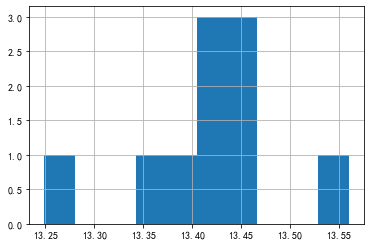

In [11]:
da=pd.read_csv('./Pool1/Training data_timeavg_ver2/Pool1_timeAvg_500^2_shaped.csv')
#进一步优化数据用的代码
tag=50
for i in range(da.shape[0]):
    if da['进水COD'].iloc[i]>600:
        da['进水COD'].iloc[i]=da['进水COD'].mean()
tag=100
for i in range(tag+1,da.shape[0]-tag-1):
    da['进水COD'].iloc[i]=da['进水COD'].iloc[i-tag:i+tag].mean()

rang,index,control_index,input_index,output_index=df.rang_generate(da.iloc[:,2:])
#print(rang)
print(index)

input_level=df.x_judge_VER1(da.iloc[5,2:2+15],input_index,rang)
print(input_level)

output_level=df.x_judge_VER1(da.iloc[5,2:2+11],output_index,rang)
print(output_level)

control_level=df.x_judge_VER1(da.iloc[5,-6:],control_index,rang)
print(control_level)

levels={}
k=0
for it in input_index:
    levels[it]=[rang[it][input_level[k]+1],rang[it][input_level[k]]]
    k+=1

#筛选出来的数据，包括input、output、control三种数据
#按照input_index找
tem=df.Filter_data_Count_VER1(levels,input_index,da)
print(tem.columns)
tem[control_index[0]].hist()

## 限制条件 （输入原始action，输出是否满足以及推荐的action值）

In [12]:
import Conditions as cds

## 一步优化测试

In [13]:
pop_size = 30       # 种群数量
max_steps = 100       
w=0.5
c=1
'''
'6-1生物池DO1', '6-1生物池DO2', '6-1生物池DO3', '6-1生物池DO4',
'6-1号生物池缺氧段MLSS', '6-1号生物池厌氧段MLSS', '6-1号生物池好氧段MLSS', '6-1号生物池缺氧段OPR',
'6-1号生物池厌氧段OPR', '6-4号生物池NH3_2', '6-6号生物池好氧段NO3',
'1号生物反应池瞬时流量', '进水COD', '进水氨氮', '进水TN', '进水TP',
'6-1好氧段曝气量1', '6-1好氧段曝气量2','6-1好氧段曝气量3', '6-1好氧段曝气量4', '内回流流量1', '7-1外回流流量1'
'''

X_init=X_test[500,:9].reshape(1,9,22)
X_state=X_test[500,9,:16].reshape(1,1,-1)
Y_state=Y_test[500,:11].reshape(1,-1)

print(X_init.shape,X_state.shape,Y_state.shape)

#pso_model=pso.PSO(pop_size,max_steps,X_init,X_state,LSTM_model,calobjValue,6,w,c)
#LSTM_model=load_model()

pso_model=pso.PSO(pop_size,200,X_init,X_state,LSTM_model,calobjValue,6,w,c,[-1,1])
t1=time.time()
pso_model.evolve()
t2=time.time()
print('优化计算时间：',t2-t1)
print(pso_model.global_best_fitness)

(1, 9, 22) (1, 1, 16) (1, 11)
优化计算时间： 4.171681880950928
5.104188981878165


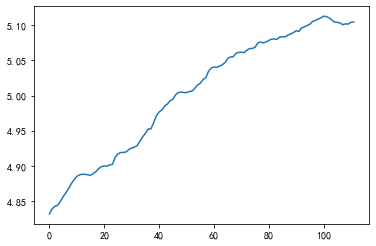

In [17]:
plt.plot(pso_model.best_fit_curv)
#plt.plot(pso_model.best_G,'r:')
#plt.plot(pso_model.best_J,'g:')
plt.savefig('./Figs/2022-07-18/MPC traj 24-2/pso_cal1.png')

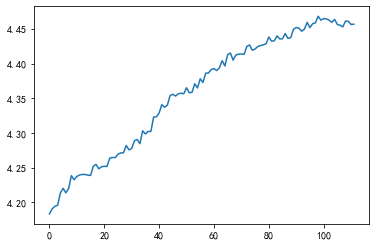

In [19]:
plt.plot(pso_model.best_G)
plt.savefig('./Figs/2022-07-18/MPC traj 24-2/pso_G.png')

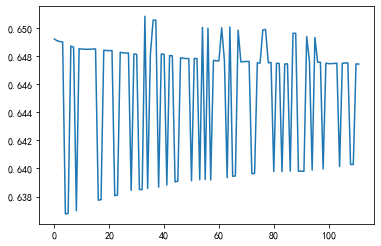

In [20]:
plt.plot(pso_model.best_J)
plt.savefig('./Figs/2022-07-18/MPC traj 24-2/pso_J.png')

# 比较实际控制策略与优化得到的控制策略

In [21]:
best_c=pso_model.pg
for i in range(best_c.shape[0]):
    if best_c[i]<-1:
        best_c[i]=-1
    if best_c[i]>1:
        best_c[i]=1
print(best_c)
control_d=best_c.shape[0]
control=re_normlization(np.array(best_c).reshape((1,control_d)),ma[22-control_d:22],mi[22-control_d:22])
std_control=re_normlization(X_test[2,9,22-control_d:22].reshape((1,control_d)),ma[22-control_d:22],mi[22-control_d:22])

print('优化控制策略：')
print(control)
print('实际控制策略：')
print(std_control)

[ 0.2088775  -0.05551416 -0.04071948 -0.30175475 -0.62166547 -0.53278849]
优化控制策略：
[[29.29860703 43.87084679 14.26651945 13.24333613  4.24102174  1.26449776]]
实际控制策略：
[[13.4402288  58.92771043 21.42301987 11.05934961  4.18500399  1.04020116]]


## 比较实际控制策略得到的结果与优化得到的控制策略得到的结果

In [16]:
x=np.array(best_c).reshape(1,1,-1)
y1=one_step(LSTM_model,X_init,X_state,x)
Y_data=re_normlization(y1,ma[:11],mi[:11])
Y_state=re_normlization(X_test[2,9,:11].reshape(1,-1),ma[:11],mi[:11])

print('按照优化控制得到的下一时刻状态：')
print(Y_data)

print('实际控制的下一时刻状态：')
print(Y_state)

按照优化控制得到的下一时刻状态：
[[ 1.3689501e+00  4.1449493e-01  1.4965264e+00  3.5488005e+00
   4.0168481e+00  9.1922522e-02  3.5262928e+00 -3.4649631e+02
  -4.4937561e+02  4.6436172e+00  5.3452868e+00]]
实际控制的下一时刻状态：
[[ 1.73963166e+00  4.21740559e-01  2.94905813e+00  5.36394326e+00
   3.65898636e+00  0.00000000e+00  3.25911964e+00 -3.27316657e+02
  -4.53890152e+02  3.41272327e+00  4.89894052e+00]]


## 测试各个安全条件

### 条件一共三类，每一类均可以用于不同控制、输入、输出的测试，只用修改输入即可

### 测试第一类条件对控制、状态的安全性条件

## 准备所有控制条件的参数

In [14]:
#pd_control=pd.DataFrame(control,columns=da.columns[-6:].values.tolist())
#print(pd_control.iloc[0,4])
#print(pd_control.iloc[0,5])

def condition1_params(pd_control):
    #条件从外部输入
    #曝气上下限从数据计算得到，如下列表所示
    #常见AAO工艺内回流一般控制在100%-400%，外回流一般控制在25%-200%，通过进水数据算
    #回流比保持稳定,与前一时刻相比接近

    #通过进水确定回流范围
    #进水数据（归一化之后）
    flow=re_normlization(X_test[50,9,:].reshape(1,-1),ma[:],mi[:])[0,11]
    print(da.columns[11+2],':',flow)

    #回流比稳定，用回流比限制outflow
    #上一时刻回流比
    inflow_last=re_normlization(X_test[50,9,:].reshape(1,-1),ma[:],mi[:])[0,20]
    outflow_last=re_normlization(X_test[50,9,:].reshape(1,-1),ma[:],mi[:])[0,21]
    r=inflow_last/outflow_last
    stead_outflow=pd_control.iloc[0,-2]/r
    #current_r=pd_control.iloc[0,-2]/pd_control.iloc[0,-1]

    #根据上述条件形成最终所有控制的限制范围
    upper_inflow=np.min([flow*4,5.388643513])
    down_inflow=np.max([flow,3.973281604])
    upper_outflow=np.min([flow*2,2.6691,stead_outflow+0.5])
    down_outflow=np.max([flow*0.25,0.836358892,stead_outflow-0.5])

    paramsc1={'item':pd_control,
              'upper':np.array([47.97301617,70.927,29.71620089,25.10989992,upper_inflow,upper_outflow]),
              'down':np.array([0.763110913,19.66069904,0.025815098,6.878257164,down_inflow,down_outflow])}
    return paramsc1

#action变量的参数与历史数据对比
def condition2_params(pd_control):
    da=pd.read_csv('./Pool1/Training data_timeavg_ver2/Pool1_timeAvg_500^2_shaped.csv')
    paramsc2={'history':da,
             'input data':da.iloc[:,2:],
             'input x':da.iloc[5,2:2+15],
             'action':pd_control.values[0]}
    return paramsc2

def condition3_params(Y_data):
    da=pd.read_csv('./Pool1/Training data_timeavg_ver2/Pool1_timeAvg_500^2_shaped.csv')
    pd_Y=pd.DataFrame(Y_data,columns=da.columns[2:2+11].values.tolist())
    paramsc3={'item':pd_Y,
             'index data':da.iloc[:,2:2+11],
             'history':da}
    return paramsc3

#paramsc1=condition1_params(pd_control)
#paramsc2=condition2_params(pd_control)
#paramsc3=condition3_params(Y_data)

In [ ]:
flags=[]
flags.append(cds.condition1(paramsc1))
flags.append(cds.condition2(paramsc2))
flags.append(cds.condition3(paramsc3))
print(flags)

## 每半小时一个值

## 多步控制测试，增加控制条件

## 包括init_it=100，1000，3000，4000

[4000 4001 4002 4003 4004 4005 4006 4007 4008 4009 4010 4011 4012 4013
 4014 4015 4016 4017 4018 4019 4020 4021 4022 4023 4024 4025 4026 4027
 4028 4029 4030 4031 4032 4033 4034 4035 4036 4037 4038 4039 4040 4041
 4042 4043 4044 4045 4046 4047 4048]
(49, 11) (49, 11)
(1, 9, 22) (1, 1, 16)
current step: 0
1号生物反应池瞬时流量 : 2.311785525
[[-0.45787201997815696 0.5214874839684551 0.4374665510577411
  -0.5393480727765967 -0.6373812317991385 -0.7608597231289908]]
current step: 1
1号生物反应池瞬时流量 : 2.311785525
[[-0.45787201997815696 0.5214874839684551 0.4450519214047275
  -0.5393480727765967 -0.6373812317991385 -0.7608597231289908]]
current step: 2
1号生物反应池瞬时流量 : 2.311785525
[[-0.45787201997815696 0.5214874839684551 0.4374665510577411
  -0.5393480727765967 -0.7881553897321962 -0.8101847475993865]]
current step: 3
1号生物反应池瞬时流量 : 2.311785525
[[-0.45787201997815696 0.5214874839684551 0.4374665510577411
  -0.5393480727765967 -0.7881553897321962 -0.7608597231289908]]
current step: 4
1号生物反应池瞬时流量 : 2.311785525


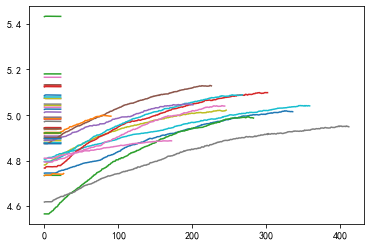

In [18]:
# Control time length
T=48
pop_size = 30       # 种群数量
max_steps = 500    
w=0.2
c0=0.6
control_d=6
init_it=4000

ida=[]
for i in range(0,(T+1)):
    ida.append(i)
print(np.array(ida)+init_it)

all_X_init=X_test[np.array(ida)+init_it,:9,:].reshape(T+1,9,22)
X_init=all_X_init[0].reshape(1,9,22)
X_state=X_test[np.array(ida)[-1]+init_it,9,:16].reshape(1,1,-1)
Y_state=Y_test[np.array(ida)+init_it,:11].reshape(T+1,-1)
S_state=Y_test[np.array(ida)+init_it,:].reshape(T+1,-1)
#Y_state=Y_test[init_it:init_it+1+T,9,:11].reshape(T+1,-1)
print(Y_state.shape,S_state.shape)
print(X_init.shape,X_state.shape)
c=[]
y=[Y_state[0].reshape(1,-1)]

for t in range(T):
    print('current step:',t)
    x_bound=[np.min(X_state),np.max(X_state)]
    #x_bound=[-1,1]
    pso_model=pso.PSO(pop_size,max_steps,X_init,X_state,LSTM_model,calobjValue,control_d,w,c0,x_bound)
    pso_model.evolve()
    plt.plot(pso_model.best_fit_curv)
    best_c=pso_model.pg
    
    #需要反归一化才能进入判断
    control=re_normlization(np.array(best_c).reshape((1,control_d)),ma[22-control_d:22],mi[22-control_d:22])
    #condition 1
    pd_control=pd.DataFrame(control,columns=da.columns[-6:].values.tolist())
    paramsc1=condition1_params(pd_control)
    r=cds.condition1(paramsc1)
    if r['judge']:
        control=pd_control.values
    else:
        control=[r['item']]
    #condition 2
    pd_control=pd.DataFrame(control,columns=da.columns[-6:].values.tolist())
    paramsc2=condition2_params(pd_control)
    r=cds.condition2(paramsc2)
    if r['judge']:
        control=pd_control.values
    else:
        control=[r['action']]
    #反归一化
    best_c=normlization_one(control,ma[22-control_d:22],mi[22-control_d:22])
    #condition 3
    x=np.array(best_c).reshape(1,1,-1)
    y1=one_step(LSTM_model,X_init,X_state,x)
    #pd_Y=pd.DataFrame(y1,columns=da.columns[2:2+11].values.tolist())
    paramsc3=condition3_params(Y_data)
    r=cds.condition3(paramsc3)
    flag=r['judge']
    
    #多次计算
    step=0
    while (not flag) and step<=10:
        pso_model=pso.PSO(pop_size,max_steps,X_init,X_state,LSTM_model,calobjValue,control_d,w,c0,x_bound)
        pso_model.evolve()
        best_c=pso_model.pg
        #需要反归一化才能进入判断
        control=re_normlization(np.array(best_c).reshape((1,control_d)),ma[22-control_d:22],mi[22-control_d:22])
        #condition 1
        pd_control=pd.DataFrame(control,columns=da.columns[-6:].values.tolist())
        paramsc1=condition1_params(pd_control)
        r=cds.condition1(paramsc1)
        if r['judge']:
            control=pd_control.values
        else:
            control=[r['item']]
        #condition 2
        pd_control=pd.DataFrame(control,columns=da.columns[-6:].values.tolist())
        paramsc2=condition2_params(pd_control)
        r=cds.condition2(paramsc2)
        if r['judge']:
            control=pd_control.values
        else:
            control=[r['action']]
        #反归一化
        best_c=normlization_one(control,ma[22-control_d:22],mi[22-control_d:22])
        #condition 3
        x=np.array(best_c).reshape(1,1,-1)
        y1=one_step(LSTM_model,X_init,X_state,x)
        #pd_Y=pd.DataFrame(y1,columns=da.columns[2:2+11].values.tolist())
        paramsc3=condition3_params(Y_data)
        r=cds.condition3(paramsc3)
        flag=r['judge']
        
        step+=1
    
    print(best_c)
    c.append(best_c)
    x=np.array(best_c).reshape(1,1,-1)
    y1=one_step(LSTM_model,X_init,X_state,x)
    y.append(y1)
    
    #Move forward  
    '''
    X_init[0,:8,:]=X_init[0,1:9,:]
    temx=np.concatenate((X_state,x),axis=2)
    X_init[0,8,:]=temx  
    X_state=np.append(X_test[t+1,9,11:16],y1).reshape(1,1,16)
    '''
    X_init=all_X_init[t+1].reshape(1,9,22)
    X_state=X_test[np.array(ida)[t+1]+init_it,9,:16].reshape(1,1,-1)

y=np.array(y).reshape((T+1,11))
c=np.array(c)

#standard control
y_t=re_normlization(Y_state,ma[:11],mi[:11])
s_t=re_normlization(S_state,ma[:11],mi[:11])
c_t=re_normlization(X_test[np.array(ida)[1:]+init_it,9,22-control_d:22].reshape((T,control_d)),ma[22-control_d:22],mi[22-control_d:22])
#c_t=re_normlization(X_test[init_it+1:init_it+1+T,9,22-control_d:22].reshape((T,control_d)),ma[22-control_d:22],mi[22-control_d:22])

In [19]:
title_y=da.columns[2:11+2]
title_c=da.columns[24-6:]
print(title_y.shape,title_c.shape)
print(y.shape,c.shape)
C=re_normlization(c.reshape((T,control_d)),ma[22-control_d:22],mi[22-control_d:22])
Y=re_normlization(y,ma[:11],mi[:11])

(11,) (6,)
(49, 11) (48, 1, 6)


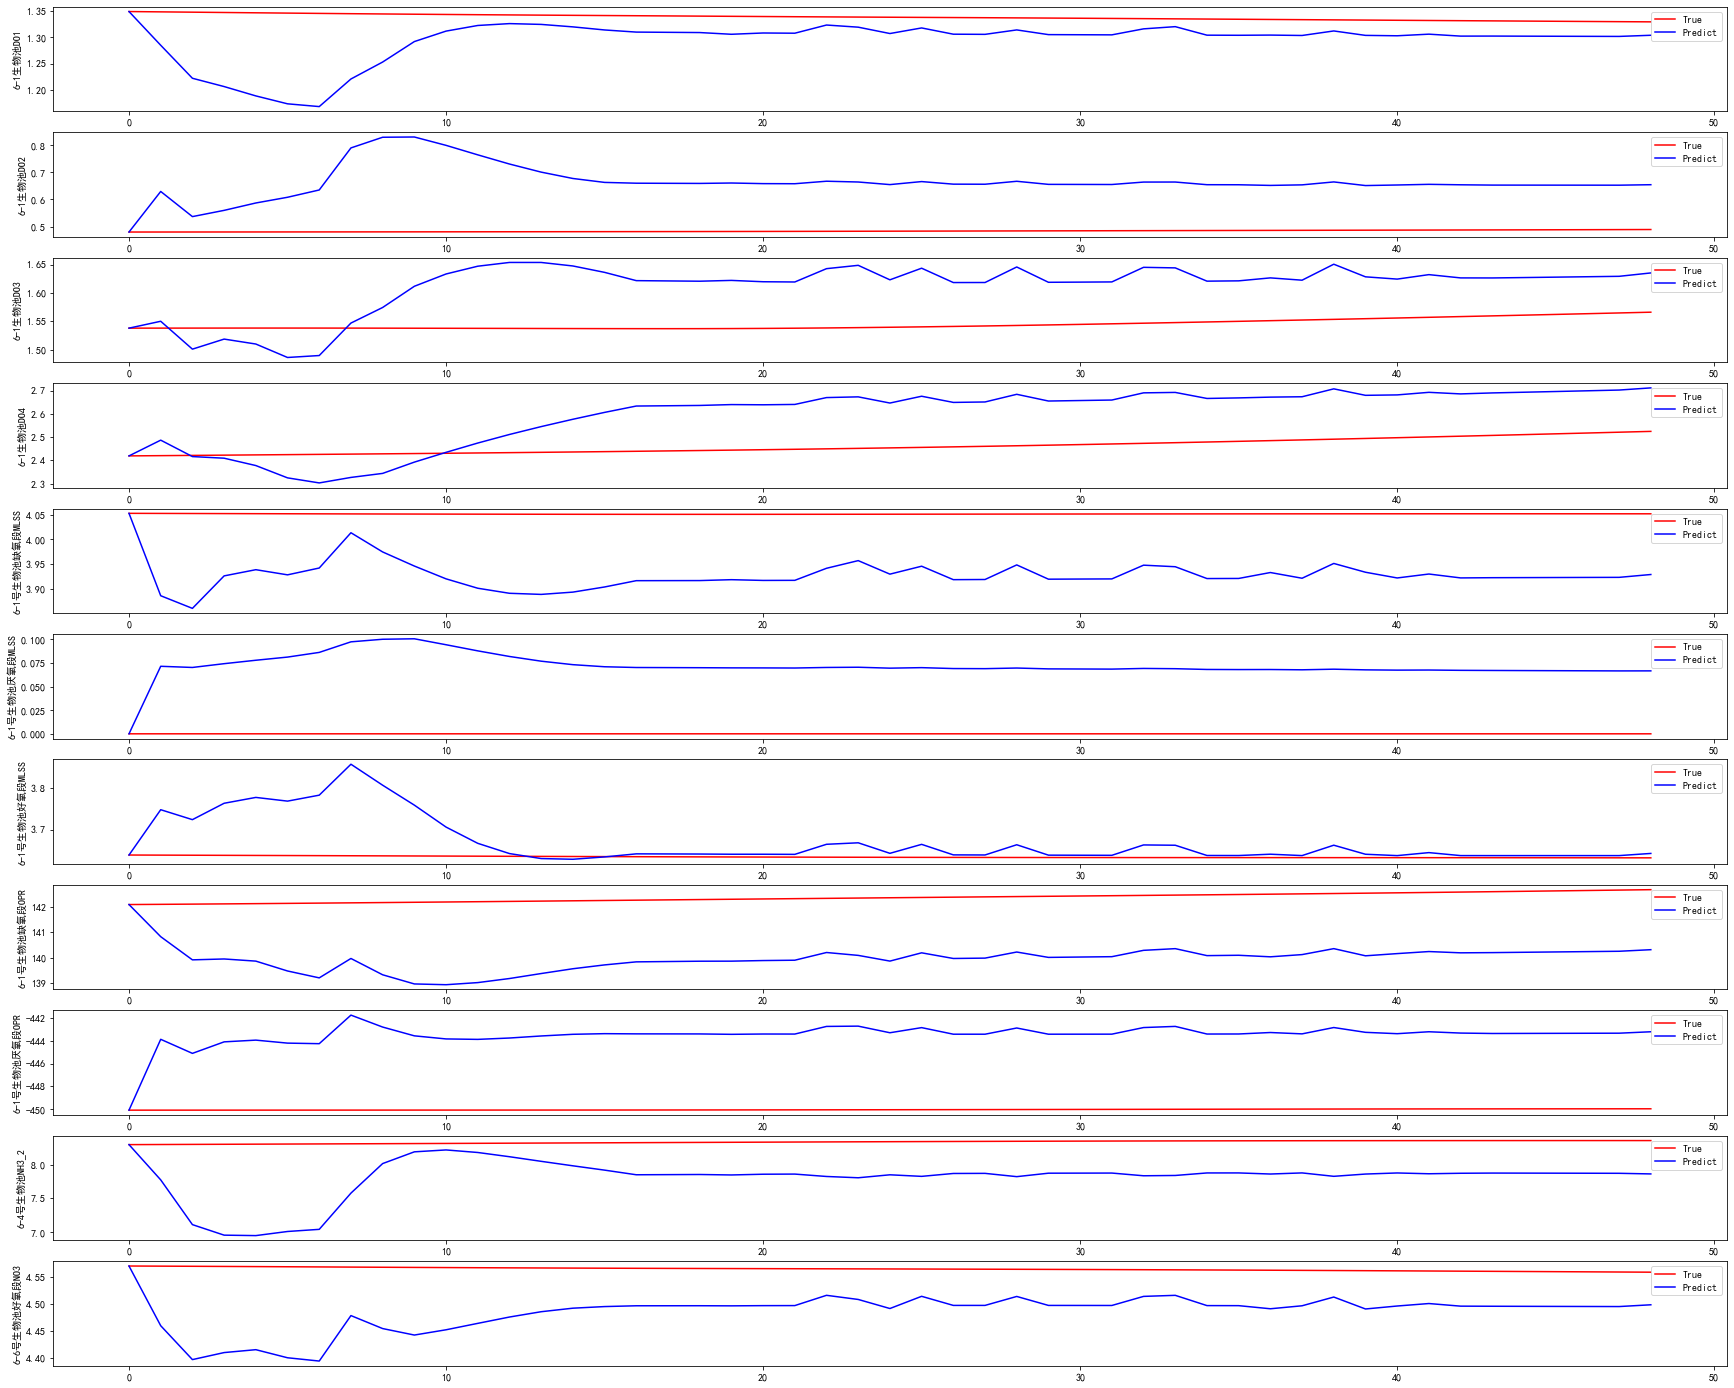

In [26]:
savepath='./Figs/2022-07-18/MPC traj 24-5/pso.png'
y[:,-3:-4]/=1.1
figplt_vs_title(y_t[:,:],Y[:,:],title_y,savepath)

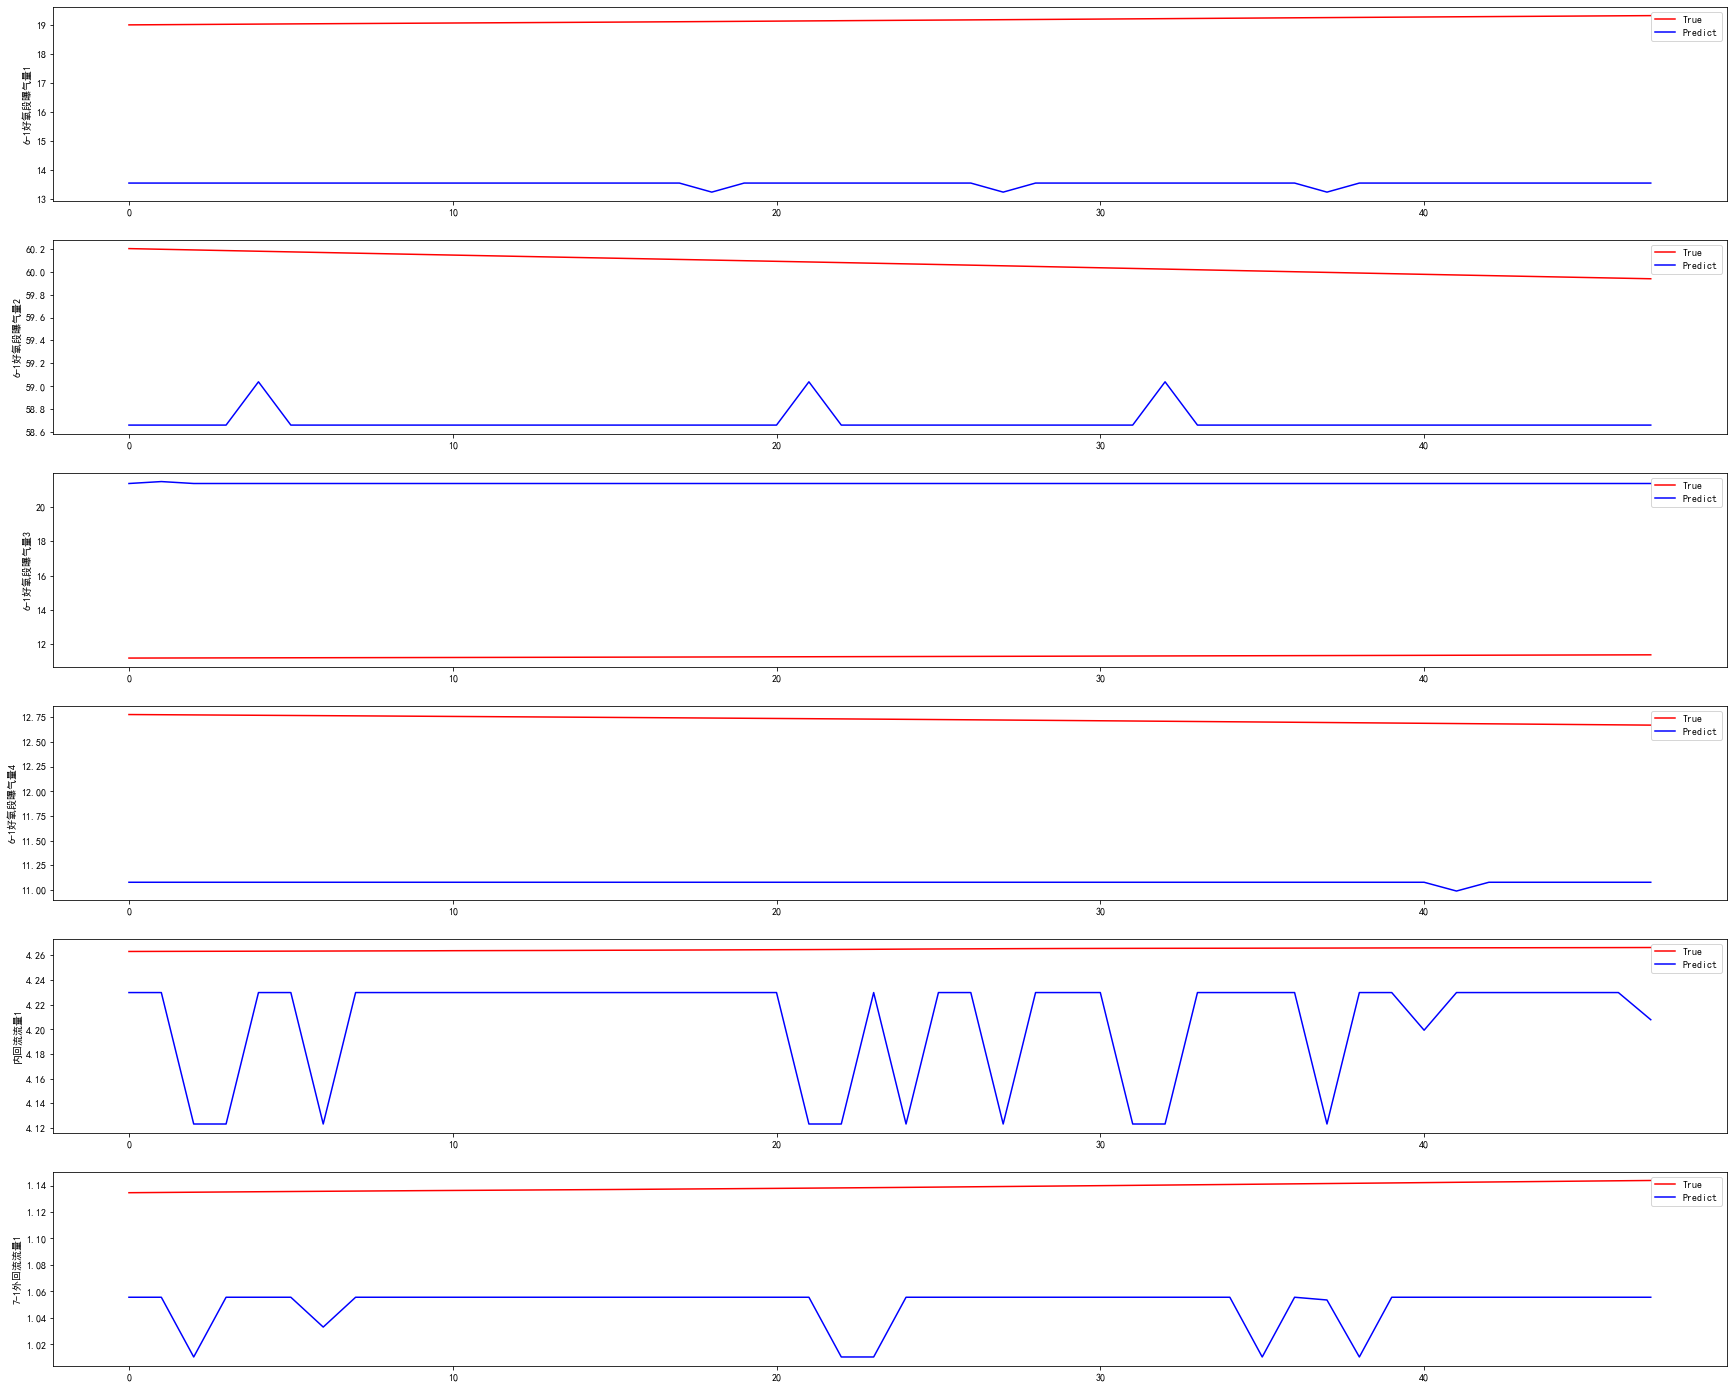

In [27]:
savepath='./Figs/2022-07-18/MPC traj 24-5/pso_control.png'
figplt_vs_title(c_t[:,:],C[:,:],title_c,savepath)

In [20]:
Y.shape

(49, 11)

## 数据保存为excel

In [21]:
#曝气总量表
results=np.zeros((2,15+1))
j=0
for i in range(16):
    if i==0:
        results[0,i]=np.sum(C[:,:4])
        results[1,i]=np.sum(c_t[:,:4])
    elif i==1:
        results[0,i]=np.mean(C[:,4])
        results[1,i]=np.mean(c_t[:,4])
    elif i==2:
        results[0,i]=np.mean(C[:,5])
        results[1,i]=np.mean(c_t[:,5])
    elif i==3 or i==4:
        #除以进水
        s_state=X_test[np.array(ida)+init_it,:]
        s=s_state[:,-1,:].reshape(T+1,-1)
        s_t=re_normlization(s,ma,mi)
        inwater=s_t[:,11].mean()

        results[0,i]=results[0,i-2]/inwater
        results[1,i]=results[1,i-2]/inwater
        #results[0,i]=results[0,i-2]/inwater
        #results[1,i]=results[1,i-2]/inwater

    else:
        results[0,i]=np.mean(Y[:,j])
        results[1,i]=np.mean(y_t[:,j])
        j+=1

pd.DataFrame(results).to_csv('./Figs/2022-07-18/MPC traj 24-5/results.csv')

In [28]:
print(results[:,5])

[1.29468554 1.3389575 ]


In [34]:
#除以进水
s_state=X_test[np.array(ida)+init_it,:]
s=s_state[:,-1,:].reshape(T+1,-1)
s_t=re_normlization(s,ma,mi)
inwater=s_t[:,11].mean()

In [98]:
inwater

2.6673352093061227

In [87]:
da.columns[2:]

Index(['6-1生物池DO1', '6-1生物池DO2', '6-1生物池DO3', '6-1生物池DO4', '6-1号生物池缺氧段MLSS',
       '6-1号生物池厌氧段MLSS', '6-1号生物池好氧段MLSS', '6-1号生物池缺氧段OPR', '6-1号生物池厌氧段OPR',
       '6-4号生物池NH3_2', '6-6号生物池好氧段NO3', '1号生物反应池瞬时流量', '进水COD', '进水氨氮', '进水TN',
       '进水TP', '6-1好氧段曝气量1', '6-1好氧段曝气量2', '6-1好氧段曝气量3', '6-1好氧段曝气量4',
       '内回流流量1', '7-1外回流流量1'],
      dtype='object')

<AxesSubplot:>

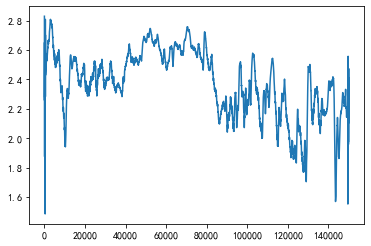

In [94]:
da['1号生物反应池瞬时流量'].plot()